# Fig 6: ENCODE Validation — Restructured

Generates TWO separate figures:

**Main Figure 6** (2 panels):
- **(A)** Enrichment heatmap — Fisher's exact test odds ratios
- **(B)** Violin plots — Attention by ENCODE bin class (Cohen's d, Kruskal-Wallis)

**Supplementary Figure 1** (2 panels):
- **(a)** Circular permutation test — observed vs null distributions
- **(b)** Threshold robustness — enrichment across top 5-20% thresholds

Changes from original NB7:
- Split into main + supplementary
- Panel B (perm): removed arrows, alpha 0.3→0.5, added p-value text
- Panel C (threshold): legend moved outside with bbox_to_anchor

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.stats import fisher_exact, kruskal
import glob
import requests, gzip

# ── Publication figure settings (Nature Methods) ──
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 8
plt.rcParams['axes.titlesize'] = 9
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['pdf.fonttype'] = 42

COL_2 = 180 / 25.4  # double column = 180mm

MARK_COLORS = {
    'CTCF': '#e41a1c', 'H3K27ac': '#ff7f00', 'H3K4me1': '#4daf4a',
    'H3K4me3': '#377eb8', 'DNase': '#984ea3',
}
CLASS_COLORS = {
    'promoter': '#377eb8', 'active_enhancer': '#ff7f00',
    'enhancer': '#4daf4a', 'CTCF': '#e41a1c', 'other': '#cccccc',
}

print('Imports OK')

Imports OK


In [3]:
# ── Paths ──
NB6_OUTPUT = Path('/content/drive/MyDrive/cdt_outputs/morris_deep_attention')
OUTPUT_BASE = Path('/content/drive/MyDrive/cdt_outputs/morris_pub_figures')
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

# ── Load NB6 attention matrices ──
npz_files = sorted(glob.glob(str(NB6_OUTPUT / 'deep_attention_matrices_*.npz')))
NPZ_PATH = Path(npz_files[-1])
print(f'Loading: {NPZ_PATH.name}')

npz = np.load(NPZ_PATH, allow_pickle=True)
npz_genes = list(npz['genes'])
print(f'Genes: {npz_genes}')

full_attn = {}
for gene in npz_genes:
    full_attn[gene] = {
        'cross_attn': npz[f'{gene}_cross_attn'],
    }
    print(f'  {gene}: cross_attn {full_attn[gene]["cross_attn"].shape}')

print('Attention loaded.')

Loading: deep_attention_matrices_20260208_181845.npz
Genes: [np.str_('CD44'), np.str_('CD52'), np.str_('GFI1B'), np.str_('TFRC'), np.str_('TNFSF9')]
  CD44: cross_attn (8, 2361, 896)
  CD52: cross_attn (8, 2361, 896)
  GFI1B: cross_attn (8, 2361, 896)
  TFRC: cross_attn (8, 2361, 896)
  TNFSF9: cross_attn (8, 2361, 896)
Attention loaded.


In [4]:
# ── ENCODE data loading ──
import h5py

DRIVE_BASE = Path('/content/drive/MyDrive/cdt_data')
TSS_ENFORMER_PATH = DRIVE_BASE / 'morris_28genes_enformer.h5'

with h5py.File(TSS_ENFORMER_PATH, 'r') as f:
    tss_coords = f['tss_coords'][:]
    tss_chroms = [c.decode() if isinstance(c, bytes) else c for c in f['chroms'][:]]
    tss_enformer_genes = [g.decode() if isinstance(g, bytes) else g for g in f['gene_names'][:]]
tss_gene_to_enformer = {g: i for i, g in enumerate(tss_enformer_genes)}

ENFORMER_BIN_SIZE = 128
ENFORMER_N_BINS = 896
ENFORMER_CENTER_BIN = 448

ENCODE_FILES = {
    'CTCF': {'accession': 'ENCFF769AUF'},
    'H3K27ac': {'accession': 'ENCFF864OSZ'},
    'H3K4me1': {'accession': 'ENCFF135ZLM'},
    'H3K4me3': {'accession': 'ENCFF313FYW'},
    'DNase': {'accession': 'ENCFF422QRZ'},
}

def download_encode(accession, cache_dir=None):
    if cache_dir is None:
        cache_dir = OUTPUT_BASE / 'encode_cache'
        cache_dir.mkdir(exist_ok=True)
    cache_file = cache_dir / f'{accession}.bed'
    if cache_file.exists():
        with open(cache_file) as f:
            lines = f.readlines()
    else:
        url = f'https://www.encodeproject.org/files/{accession}/@@download/{accession}.bed.gz'
        print(f'  Downloading {accession}...')
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        content = gzip.decompress(r.content).decode('utf-8')
        lines = content.strip().split('\n')
        with open(cache_file, 'w') as f:
            f.write(content)
    peaks = []
    for line in lines:
        if line.startswith('#') or not line.strip():
            continue
        flds = line.strip().split('\t')
        if len(flds) < 7:
            continue
        peaks.append({'chrom': flds[0], 'start': int(flds[1]), 'end': int(flds[2]),
                      'signalValue': float(flds[6]) if len(flds) > 6 else 0})
    return peaks

def peaks_to_binary(peaks, chrom, tss, n_bins=896, bin_size=128):
    binary = np.zeros(n_bins, dtype=np.float32)
    center = n_bins // 2
    region_start = tss + (0 - center) * bin_size
    region_end = tss + (n_bins - 1 - center) * bin_size + bin_size
    for p in peaks:
        if p['chrom'] != chrom or p['end'] <= region_start or p['start'] >= region_end:
            continue
        for b in range(n_bins):
            bs = tss + (b - center) * bin_size
            be = bs + bin_size
            if p['start'] < be and p['end'] > bs:
                binary[b] = 1.0
    return binary

# Download and build binary maps
encode_peaks = {}
for mark, info in ENCODE_FILES.items():
    encode_peaks[mark] = download_encode(info['accession'])
    print(f'  {mark}: {len(encode_peaks[mark])} peaks')

encode_bin_binary = {}
for gene in npz_genes:
    enf_idx = tss_gene_to_enformer[gene]
    tss = tss_coords[enf_idx]
    chrom = tss_chroms[enf_idx]
    encode_bin_binary[gene] = {}
    for mark, peaks in encode_peaks.items():
        encode_bin_binary[gene][mark] = peaks_to_binary(peaks, chrom, tss)

print(f'ENCODE bin maps built for {len(encode_bin_binary)} genes')

  CTCF: 51759 peaks
  H3K27ac: 51343 peaks
  H3K4me1: 99180 peaks
  H3K4me3: 29544 peaks
  DNase: 58261 peaks
ENCODE bin maps built for 5 genes


In [5]:
# ── Enrichment + helper functions ──

def compute_enrichment(importance, binary, top_percentile=90):
    thresh = np.percentile(importance, top_percentile)
    top = importance >= thresh
    hit = binary > 0
    a = int((top & hit).sum())
    b = int((top & ~hit).sum())
    c = int((~top & hit).sum())
    d = int((~top & ~hit).sum())
    table = np.array([[a, b], [c, d]])
    or_val, p_val = fisher_exact(table, alternative='greater')
    aa, bb, cc, dd = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    log_or = np.log(aa * dd / (bb * cc))
    se = np.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
    ci_low = np.exp(log_or - 1.96 * se)
    ci_high = np.exp(log_or + 1.96 * se)
    return {'or': or_val, 'p': p_val, 'ci_low': ci_low, 'ci_high': ci_high,
            'a': a, 'b': b, 'c': c, 'd': d}

def classify_bins(encode_binary_gene):
    n = 896
    labels = np.array(['other'] * n, dtype='U20')
    h3k4me3 = encode_binary_gene.get('H3K4me3', np.zeros(n))
    h3k4me1 = encode_binary_gene.get('H3K4me1', np.zeros(n))
    h3k27ac = encode_binary_gene.get('H3K27ac', np.zeros(n))
    ctcf = encode_binary_gene.get('CTCF', np.zeros(n))
    labels[h3k4me3 > 0] = 'promoter'
    labels[(h3k4me1 > 0) & (h3k4me3 == 0)] = 'enhancer'
    labels[(h3k27ac > 0) & (h3k4me3 == 0)] = 'active_enhancer'
    labels[(ctcf > 0) & (h3k4me3 == 0) & (h3k4me1 == 0)] = 'CTCF'
    return labels

def circular_permutation_test(importance, binary, n_perm=1000, top_percentile=90):
    observed = compute_enrichment(importance, binary, top_percentile)
    observed_or = observed['or']
    n_bins = len(importance)
    null_ors = np.zeros(n_perm)
    for k in range(n_perm):
        shift = np.random.randint(1, n_bins)
        shifted = np.roll(importance, shift)
        null_r = compute_enrichment(shifted, binary, top_percentile)
        null_ors[k] = null_r['or']
    p_perm = (null_ors >= observed_or).sum() / n_perm
    return {'observed_or': observed_or, 'null_ors': null_ors, 'p_perm': p_perm,
            'null_mean': null_ors.mean(), 'null_std': null_ors.std()}

print('Functions defined.')

Functions defined.


In [6]:
# ── Compute all data needed for the 4-panel figure ──
marks_ordered = ['DNase', 'CTCF', 'H3K4me3', 'H3K27ac', 'H3K4me1']
test_marks = ['DNase', 'CTCF', 'H3K4me3']

# Panel A: enrichment heatmap
enrichment_results = {}
or_matrix = np.zeros((len(npz_genes), len(marks_ordered)))
pval_matrix = np.ones((len(npz_genes), len(marks_ordered)))

for i, gene in enumerate(npz_genes):
    cross_attn = full_attn[gene]['cross_attn']
    dna_profile = cross_attn.mean(axis=(0, 1))
    enrichment_results[gene] = {}
    for j, mark in enumerate(marks_ordered):
        binary = encode_bin_binary[gene][mark]
        if binary.sum() == 0:
            enrichment_results[gene][mark] = {'or': np.nan, 'p': 1.0}
            continue
        r = compute_enrichment(dna_profile, binary, top_percentile=90)
        enrichment_results[gene][mark] = r
        or_matrix[i, j] = r['or'] if not np.isnan(r['or']) else 0
        pval_matrix[i, j] = r['p']

print('Panel A: enrichment computed')

# Panel B: permutation test (GFI1B)
np.random.seed(42)
perm_results = {}
gene_perm = 'GFI1B'
cross_attn_perm = full_attn[gene_perm]['cross_attn']
dna_profile_perm = cross_attn_perm.mean(axis=(0, 1))
perm_results[gene_perm] = {}

for mark in test_marks:
    binary = encode_bin_binary[gene_perm][mark]
    if binary.sum() < 5:
        continue
    pr = circular_permutation_test(dna_profile_perm, binary, n_perm=1000)
    perm_results[gene_perm][mark] = pr
    print(f'  Panel B: {gene_perm} x {mark}: OR={pr["observed_or"]:.2f}, p={pr["p_perm"]:.4f}')

print('Panel B: permutation computed')

# Panel D: bin class data (all genes)
all_data = {'class': [], 'attn': [], 'gene': []}
for gene in npz_genes:
    cross_attn = full_attn[gene]['cross_attn']
    dna_profile = cross_attn.mean(axis=(0, 1))
    labels = classify_bins(encode_bin_binary[gene])
    for b in range(896):
        all_data['class'].append(labels[b])
        all_data['attn'].append(dna_profile[b])
        all_data['gene'].append(gene)
all_data = {k: np.array(v) for k, v in all_data.items()}

print(f'Panel D: {len(all_data["class"])} bins classified')
print('All computations done.')

Panel A: enrichment computed
  Panel B: GFI1B x DNase: OR=201.25, p=0.0000
  Panel B: GFI1B x CTCF: OR=27.05, p=0.0000
  Panel B: GFI1B x H3K4me3: OR=10.53, p=0.0000
Panel B: permutation computed
Panel D: 4480 bins classified
All computations done.


## Generate restructured figures

**Main Figure 6**: Panel A (heatmap) + Panel B (violin)
**Supplementary Figure 1**: Panel a (permutation) + Panel b (threshold)

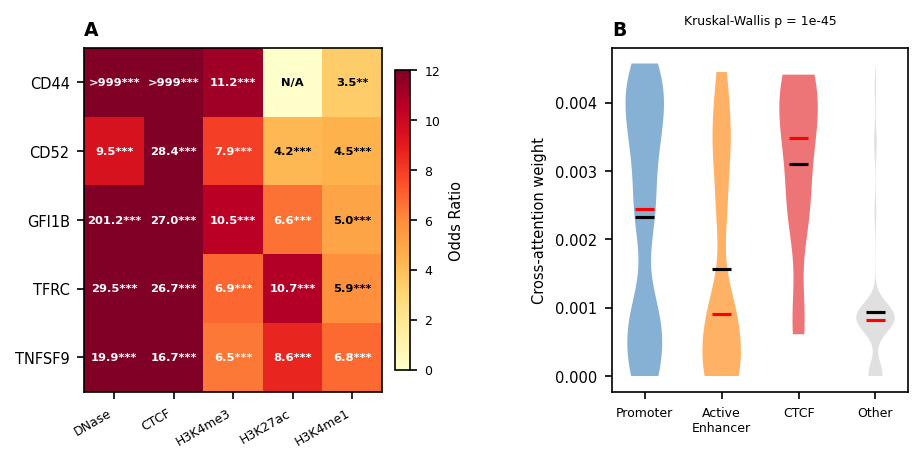

Main Figure 6 saved (Panel A + B)
  /content/drive/MyDrive/cdt_outputs/morris_pub_figures/fig6_main_encode.png


In [7]:
# ══════════════════════════════════════════════════════════════════
# MAIN FIGURE 6 — Panel A (heatmap) + Panel B (violin)
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(COL_2, COL_2 * 0.42),
                         gridspec_kw={'width_ratios': [1.1, 1], 'wspace': 0.65})

# ── Panel A: Cross-gene enrichment heatmap ──
ax = axes[0]
or_capped = np.clip(or_matrix, 0, 12)
im = ax.imshow(or_capped, cmap='YlOrRd', aspect='auto', vmin=0, vmax=12)
for i in range(len(npz_genes)):
    for j in range(len(marks_ordered)):
        val = or_matrix[i, j]
        p = pval_matrix[i, j]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if np.isinf(val):
            text = f'>999{sig}'
        elif val > 0 and not np.isnan(val):
            text = f'{val:.1f}{sig}'
        else:
            text = 'N/A'
        color = 'white' if or_capped[i, j] > 6 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=5.5,
                color=color, fontweight='bold')
ax.set_xticks(range(len(marks_ordered)))
ax.set_xticklabels(marks_ordered, fontsize=6, rotation=30, ha='right')
ax.set_yticks(range(len(npz_genes)))
ax.set_yticklabels(npz_genes, fontsize=7)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelsize=6)
cb.set_label('Odds Ratio', fontsize=7)
ax.set_title('A', fontsize=9, fontweight='bold', loc='left')

# ── Panel B: Bin class violin ──
ax = axes[1]
plot_classes_d = ['promoter', 'active_enhancer', 'CTCF', 'other']
data_groups_d = []
for cls in plot_classes_d:
    mask = all_data['class'] == cls
    data_groups_d.append(all_data['attn'][mask])

parts = ax.violinplot(data_groups_d, positions=range(len(plot_classes_d)),
                       showmeans=True, showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(CLASS_COLORS[plot_classes_d[i]])
    pc.set_alpha(0.6)
parts['cmeans'].set_color('black')
parts['cmedians'].set_color('red')
ax.set_xticks(range(len(plot_classes_d)))
ax.set_xticklabels(['Promoter', 'Active\nEnhancer', 'CTCF', 'Other'], fontsize=6)
ax.set_ylabel('Cross-attention weight', fontsize=7)
ax.set_title('B', fontsize=9, fontweight='bold', loc='left')

valid_d = [g for g in data_groups_d if len(g) >= 3]
if len(valid_d) >= 2:
    H, p = kruskal(*valid_d)
    ax.text(0.5, 1.06, f'Kruskal-Wallis p = {p:.0e}', transform=ax.transAxes,
            fontsize=6, ha='center', va='bottom')

# ── Save main figure ──
plt.savefig(OUTPUT_BASE / 'fig6_main_encode.pdf', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'fig6_main_encode.png', dpi=300, bbox_inches='tight')
plt.show()
print('Main Figure 6 saved (Panel A + B)')
print(f'  {OUTPUT_BASE / "fig6_main_encode.png"}')

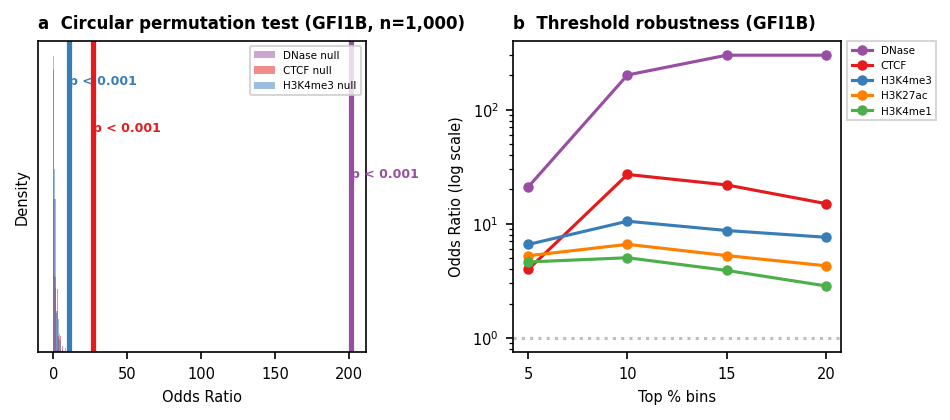

Supplementary Figure 1 saved (Panel a + b)
  /content/drive/MyDrive/cdt_outputs/morris_pub_figures/supp_fig1_encode_robustness.png


In [8]:
# ══════════════════════════════════════════════════════════════════
# SUPPLEMENTARY FIGURE 1 — Panel a (permutation) + Panel b (threshold)
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(COL_2, COL_2 * 0.38))
plt.subplots_adjust(wspace=0.45, right=0.88)

# ── Panel a: Circular permutation test — FIXED ──
ax = axes[0]
for k, mark in enumerate(test_marks):
    if mark not in perm_results.get(gene_perm, {}):
        continue
    pr = perm_results[gene_perm][mark]
    color = MARK_COLORS[mark]
    ax.hist(pr['null_ors'], bins=25, alpha=0.5, color=color,
            density=True, label=f'{mark} null')
    ax.axvline(pr['observed_or'], color=color, linewidth=2.5, linestyle='-')

# p-value text after ylim is set
y_top = ax.get_ylim()[1]
for k, mark in enumerate(test_marks):
    if mark not in perm_results.get(gene_perm, {}):
        continue
    pr = perm_results[gene_perm][mark]
    color = MARK_COLORS[mark]
    p_text = 'p < 0.001' if pr['p_perm'] == 0 else f'p = {pr["p_perm"]:.3f}'
    ax.text(pr['observed_or'] + 0.15, y_top * (0.55 + k * 0.15),
            p_text, fontsize=6, color=color, fontweight='bold',
            ha='left', va='bottom', rotation=0)

ax.set_xlabel('Odds Ratio', fontsize=7)
ax.set_ylabel('Density', fontsize=7)
ax.legend(fontsize=5, loc='upper right')
ax.set_title(f'a  Circular permutation test ({gene_perm}, n=1,000)', fontsize=8,
             fontweight='bold', loc='left')
ax.set_yticks([])

# ── Panel b: Threshold robustness — FIXED ──
ax = axes[1]
gene_c = 'GFI1B'
thresholds_c = [95, 90, 85, 80]
x_c = [100 - t for t in thresholds_c]
cross_attn_c = full_attn[gene_c]['cross_attn']
dna_profile_c = cross_attn_c.mean(axis=(0, 1))

for mark in marks_ordered:
    binary = encode_bin_binary[gene_c][mark]
    if binary.sum() == 0:
        continue
    ors = []
    for t in thresholds_c:
        r = compute_enrichment(dna_profile_c, binary, top_percentile=t)
        or_val = r['or'] if not np.isinf(r['or']) else 300
        ors.append(or_val)
    ax.plot(x_c, ors, 'o-', color=MARK_COLORS[mark], label=mark,
            markersize=4, linewidth=1.5)

ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Top % bins', fontsize=7)
ax.set_ylabel('Odds Ratio (log scale)', fontsize=7)
ax.set_xticks(x_c)
ax.set_title(f'b  Threshold robustness ({gene_c})', fontsize=8,
             fontweight='bold', loc='left')
ax.legend(fontsize=5, loc='upper left', bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, frameon=True, fancybox=False, edgecolor='#cccccc')

# ── Save supplementary figure ──
plt.savefig(OUTPUT_BASE / 'supp_fig1_encode_robustness.pdf', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_BASE / 'supp_fig1_encode_robustness.png', dpi=300, bbox_inches='tight')
plt.show()
print('Supplementary Figure 1 saved (Panel a + b)')
print(f'  {OUTPUT_BASE / "supp_fig1_encode_robustness.png"}')

## Download

Download both figures, then locally:
```bash
# Main Figure 6 (Panel A + B)
cp ~/Downloads/fig6_main_encode.png figures/main/fig6_encode_validation.png

# Supplementary Figure 1 (Panel a + b)
cp ~/Downloads/supp_fig1_encode_robustness.png figures/supplementary/supp_fig1_encode_robustness.png
```

Then update `docs/cdt_ii_paper_draft.tex`:
- Main figure path: `../figures/main/fig6_encode_validation.png`
- Uncomment supplementary figure section